# Boston Housing Price Prediction using Watson Machine Learning

This notebook demonstrates how to call a deployed Watson Machine Learning model for Boston Housing price predictions.

## Dataset Features
- **CRIM**: Per capita crime rate by town
- **ZN**: Proportion of residential land zoned for lots over 25,000 sq.ft.
- **INDUS**: Proportion of non-retail business acres per town
- **CHAS**: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
- **NOX**: Nitric oxides concentration (parts per 10 million)
- **RM**: Average number of rooms per dwelling
- **AGE**: Proportion of owner-occupied units built prior to 1940
- **DIS**: Weighted distances to five Boston employment centres
- **RAD**: Index of accessibility to radial highways
- **TAX**: Full-value property-tax rate per $10,000
- **PTRATIO**: Pupil-teacher ratio by town
- **B**: 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town
- **LSTAT**: % lower status of the population
- **MEDV**: Median value of owner-occupied homes in $1000's (target variable)

## 1. Install Required Libraries

In [1]:
# Install required packages if not already installed
!uv pip install requests pandas numpy matplotlib ibm-watson-machine-learning

Using Python 3.10.19 environment at: /Users/gary/Documents/Demos/IFSA-students/.venv
Audited 5 packages in 23ms


## 2. Import Libraries

In [2]:
import requests
import json
import pandas as pd
import numpy as np
from typing import List, Dict, Any

## 3. Configuration

**Important**: You need to provide your Watson Machine Learning credentials:
- API Key
- IBM Cloud IAM Token (or the script will generate one from your API key)

In [3]:
# Watson Machine Learning Configuration
WML_DEPLOYMENT_URL = "https://us-south.ml.cloud.ibm.com/ml/v4/deployments/house_market_prediction/predictions?version=2021-05-01" # YOUR ENDPOINT

# IBM Cloud Authentication
# Option 1: Provide your API key (recommended)
import getpass
IBM_CLOUD_API_KEY = getpass.getpass("Enter your API key here.")  # Replace with your actual API key


# Feature names in the correct order
FEATURE_NAMES = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

## 4. Authentication Helper Functions

In [4]:
def get_iam_token(api_key: str) -> str:
    """
    Generate an IAM token from IBM Cloud API key.
    
    Args:
        api_key: IBM Cloud API key
        
    Returns:
        IAM access token
    """
    url = "https://iam.cloud.ibm.com/identity/token"
    headers = {
        "Content-Type": "application/x-www-form-urlencoded"
    }
    data = {
        "grant_type": "urn:ibm:params:oauth:grant-type:apikey",
        "apikey": api_key
    }
    
    response = requests.post(url, headers=headers, data=data)
    
    if response.status_code == 200:
        return response.json()["access_token"]
    else:
        raise Exception(f"Failed to get IAM token: {response.status_code} - {response.text}")


def get_auth_token() -> str:
    """
    Get authentication token (either from provided token or generate from API key).
    
    Returns:
        Authentication token
    """
    global IBM_CLOUD_API_KEY
    if IBM_CLOUD_API_KEY:
        print("Generating IAM token from API key...")
        return get_iam_token(IBM_CLOUD_API_KEY)
    else:
        raise ValueError("Please provide either IBM_CLOUD_API_KEY or IAM_TOKEN")

## 5. Prediction Function

In [5]:
def predict_house_price(input_data: List[List[float]], feature_names: List[str] = None) -> Dict[str, Any]:
    """
    Make predictions using the Watson ML deployment endpoint.
    
    Args:
        input_data: List of feature vectors (each vector is a list of 13 features)
        feature_names: Optional list of feature names
        
    Returns:
        Dictionary containing predictions and metadata
    """
    # Get authentication token
    token = get_auth_token()
    
    # Prepare headers
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {token}"
    }
    
    # Prepare payload
    payload = {
        "input_data": [
            {
                "fields": feature_names if feature_names else FEATURE_NAMES,
                "values": input_data
            }
        ]
    }
    
    # Make prediction request
    print(f"Sending prediction request for {len(input_data)} sample(s)...")
    response = requests.post(WML_DEPLOYMENT_URL, headers=headers, json=payload)
    
    if response.status_code == 200:
        result = response.json()
        print("✓ Prediction successful!")
        return result
    else:
        raise Exception(f"Prediction failed: {response.status_code} - {response.text}")


def extract_predictions(response: Dict[str, Any]) -> List[float]:
    """
    Extract prediction values from the API response.
    
    Args:
        response: API response dictionary
        
    Returns:
        List of predicted values
    """
    try:
        predictions = response['predictions'][0]['values']
        # Extract the predicted value (usually the first or last column)
        return [pred[-1] if isinstance(pred, list) else pred for pred in predictions]
    except (KeyError, IndexError) as e:
        print(f"Warning: Could not extract predictions in expected format: {e}")
        return response

## 6. Load Sample Data

In [6]:
# Load the Boston Housing dataset
df = pd.read_csv('../data/HousingData_train.csv')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
display(df.head())

print("\nDataset info:")
display(df.info())

print("\nMissing values:")
display(df.isnull().sum())

Dataset shape: (455, 14)

First few rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.03705,20.0,3.33,0.0,0.4429,6.968,NaN,5.2447,5,216,14.9,392.23,4.59,35.4
1,1.23247,0.0,8.14,0.0,0.5380,6.142,91.7,3.9769,4,307,21.0,396.90,18.72,15.2
2,0.11432,0.0,8.56,0.0,0.5200,6.781,71.3,2.8561,5,384,20.9,395.58,7.67,26.5
3,0.54050,20.0,3.97,0.0,0.5750,7.470,52.6,2.8720,5,264,13.0,390.30,3.16,43.5
4,3.67367,0.0,18.10,0.0,0.5830,6.312,51.9,3.9917,24,666,20.2,388.62,10.58,21.2



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     435 non-null    float64
 1   ZN       437 non-null    float64
 2   INDUS    436 non-null    float64
 3   CHAS     437 non-null    float64
 4   NOX      455 non-null    float64
 5   RM       455 non-null    float64
 6   AGE      437 non-null    float64
 7   DIS      455 non-null    float64
 8   RAD      455 non-null    int64  
 9   TAX      455 non-null    int64  
 10  PTRATIO  455 non-null    float64
 11  B        455 non-null    float64
 12  LSTAT    440 non-null    float64
 13  MEDV     455 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 49.9 KB


None


Missing values:


CRIM       20
ZN         18
INDUS      19
CHAS       18
NOX         0
RM          0
AGE        18
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      15
MEDV        0
dtype: int64

## 7. Prepare Test Data

Handle missing values and prepare features for prediction.

In [7]:
# Separate features and target
X = df[FEATURE_NAMES].copy()
y = df['MEDV'].copy() if 'MEDV' in df.columns else None

# Handle missing values - fill with median
X_filled = X.fillna(X.median())

print("Features after handling missing values:")
display(X_filled.head())
print("\nRemaining missing values:", X_filled.isnull().sum().sum())

Features after handling missing values:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.03705,20.0,3.33,0.0,0.4429,6.968,76.7,5.2447,5,216,14.9,392.23,4.59
1,1.23247,0.0,8.14,0.0,0.5380,6.142,91.7,3.9769,4,307,21.0,396.90,18.72
2,0.11432,0.0,8.56,0.0,0.5200,6.781,71.3,2.8561,5,384,20.9,395.58,7.67
3,0.54050,20.0,3.97,0.0,0.5750,7.470,52.6,2.8720,5,264,13.0,390.30,3.16
4,3.67367,0.0,18.10,0.0,0.5830,6.312,51.9,3.9917,24,666,20.2,388.62,10.58



Remaining missing values: 0


## 8. Example 1: Single Prediction

Make a prediction for a single house.

In [8]:
# Select first row as example
sample_input = X_filled.iloc[0:1].values.tolist()

print("Input features:")
for name, value in zip(FEATURE_NAMES, sample_input[0]):
    print(f"  {name}: {value}")

# Make prediction
try:
    response = predict_house_price(sample_input)
    predictions = extract_predictions(response)
    
    print(f"\n{'='*50}")
    print(f"Predicted house price: ${predictions[0]:.2f}k")
    
    if y is not None:
        actual = y.iloc[0]
        print(f"Actual house price: ${actual:.2f}k")
        print(f"Difference: ${abs(predictions[0] - actual):.2f}k")
    print(f"{'='*50}")
    
except Exception as e:
    print(f"Error: {e}")

Input features:
  CRIM: 0.03705
  ZN: 20.0
  INDUS: 3.33
  CHAS: 0.0
  NOX: 0.4429
  RM: 6.968
  AGE: 76.7
  DIS: 5.2447
  RAD: 5.0
  TAX: 216.0
  PTRATIO: 14.9
  B: 392.23
  LSTAT: 4.59
Generating IAM token from API key...
Sending prediction request for 1 sample(s)...
✓ Prediction successful!

Predicted house price: $34.68k
Actual house price: $35.40k
Difference: $0.72k


## 9. Example 2: Batch Predictions

Make predictions for multiple houses at once.

In [9]:
# Select first 5 rows for batch prediction
batch_input = X_filled.iloc[0:5].values.tolist()

print(f"Making predictions for {len(batch_input)} houses...\n")

try:
    response = predict_house_price(batch_input)
    predictions = extract_predictions(response)
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'Predicted_Price_k': predictions
    })
    
    if y is not None:
        results_df['Actual_Price_k'] = y.iloc[0:5].values
        results_df['Difference_k'] = abs(results_df['Predicted_Price_k'] - results_df['Actual_Price_k'])
    
    print("\nPrediction Results:")
    display(results_df)
    
    if y is not None:
        mae = results_df['Difference_k'].mean()
        print(f"\nMean Absolute Error: ${mae:.2f}k")
    
except Exception as e:
    print(f"Error: {e}")

Making predictions for 5 houses...

Generating IAM token from API key...
Sending prediction request for 5 sample(s)...
✓ Prediction successful!

Prediction Results:


,Predicted_Price_k,Actual_Price_k,Difference_k
0,34.678579,35.4,0.721421
1,15.438519,15.2,0.238519
2,26.418478,26.5,0.081522
3,35.683587,43.5,7.816413
4,21.179865,21.2,0.020135



Mean Absolute Error: $1.78k


## 10. Example 3: Custom Input

Create your own input data for prediction.

In [10]:
# Create custom input (example values)
custom_input = [[
    0.00632,  # CRIM: Crime rate
    18.0,     # ZN: Residential land zoned
    2.31,     # INDUS: Non-retail business acres
    0,        # CHAS: Charles River (0 or 1)
    0.538,    # NOX: Nitric oxides concentration
    6.575,    # RM: Average rooms per dwelling
    65.2,     # AGE: Proportion of old units
    4.09,     # DIS: Distance to employment centers
    1,        # RAD: Highway accessibility index
    296,      # TAX: Property tax rate
    15.3,     # PTRATIO: Pupil-teacher ratio
    396.9,    # B: Proportion of Black residents
    4.98      # LSTAT: Lower status population %
]]

print("Custom input features:")
for name, value in zip(FEATURE_NAMES, custom_input[0]):
    print(f"  {name}: {value}")

try:
    response = predict_house_price(custom_input)
    predictions = extract_predictions(response)
    
    print(f"\n{'='*50}")
    print(f"Predicted house price: ${predictions[0]:.2f}k")
    print(f"{'='*50}")
    
except Exception as e:
    print(f"Error: {e}")

Custom input features:
  CRIM: 0.00632
  ZN: 18.0
  INDUS: 2.31
  CHAS: 0
  NOX: 0.538
  RM: 6.575
  AGE: 65.2
  DIS: 4.09
  RAD: 1
  TAX: 296
  PTRATIO: 15.3
  B: 396.9
  LSTAT: 4.98
Generating IAM token from API key...
Sending prediction request for 1 sample(s)...
✓ Prediction successful!

Predicted house price: $28.68k


## 11. Visualize Predictions vs Actual (Optional)

Compare predictions with actual values for a larger sample.

Generating IAM token from API key...
Sending prediction request for 20 sample(s)...
✓ Prediction successful!


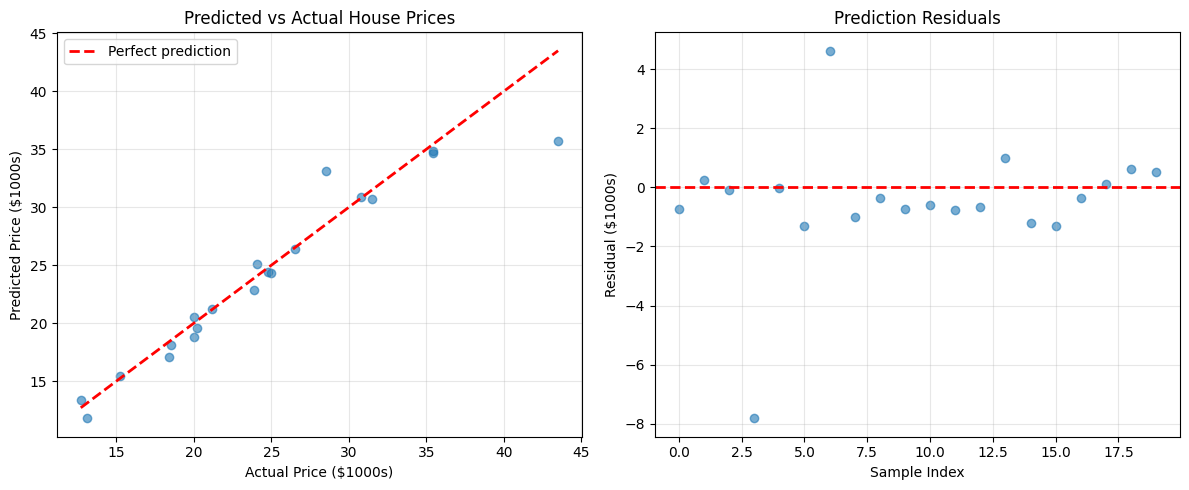


Prediction Statistics:
  Mean Absolute Error: $1.20k
  Root Mean Squared Error: $2.15k


In [11]:
import matplotlib.pyplot as plt

# Make predictions for first 20 samples
n_samples = min(20, len(X_filled))
test_input = X_filled.iloc[0:n_samples].values.tolist()

try:
    response = predict_house_price(test_input)
    predictions = extract_predictions(response)
    
    if y is not None:
        actual_values = y.iloc[0:n_samples].values
        
        # Create visualization
        plt.figure(figsize=(12, 5))
        
        # Plot 1: Predictions vs Actual
        plt.subplot(1, 2, 1)
        plt.scatter(actual_values, predictions, alpha=0.6)
        plt.plot([actual_values.min(), actual_values.max()], 
                [actual_values.min(), actual_values.max()], 
                'r--', lw=2, label='Perfect prediction')
        plt.xlabel('Actual Price ($1000s)')
        plt.ylabel('Predicted Price ($1000s)')
        plt.title('Predicted vs Actual House Prices')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Plot 2: Residuals
        plt.subplot(1, 2, 2)
        residuals = np.array(predictions) - actual_values
        plt.scatter(range(len(residuals)), residuals, alpha=0.6)
        plt.axhline(y=0, color='r', linestyle='--', lw=2)
        plt.xlabel('Sample Index')
        plt.ylabel('Residual ($1000s)')
        plt.title('Prediction Residuals')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        mae = np.mean(np.abs(residuals))
        rmse = np.sqrt(np.mean(residuals**2))
        print(f"\nPrediction Statistics:")
        print(f"  Mean Absolute Error: ${mae:.2f}k")
        print(f"  Root Mean Squared Error: ${rmse:.2f}k")
    else:
        print("No actual values available for comparison")
        
except Exception as e:
    print(f"Error: {e}")

## 12. Summary

This notebook demonstrates:
1. Authentication with IBM Watson Machine Learning
2. Making single and batch predictions
3. Handling missing values in input data
4. Comparing predictions with actual values
5. Visualizing model performance

### Next Steps:
- Experiment with different input values
- Analyze feature importance
- Test edge cases and data quality
- Integrate predictions into your application